# AXA × climat France — exploration

**Objectif:** voir s’il existe une **association** entre le cours mensuel d’**AXA** (`CS.PA`) et un agrégat **météo national français** (données régionales journalières moyennées), **en contrôlant** le **CAC 40**.

**Important:** ce notebook est exploratoire. Une corrélation ou un coefficient de régression **ne prouve pas** la causalité. AXA est un groupe **mondial** ; la météo France n’en couvre qu’une partie.

**Prérequis:** exécuter depuis le dossier `MLStudy2` (racine du projet). Fichiers : `dataSets/v2/axa_monthly_returns.csv`, `dataSets/v2/cac40_monthly_returns.csv`, `dataSets/v2/merged_daily_regional.csv`.


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path.cwd()
V2 = BASE / "dataSets" / "v2"
AXA_PATH = V2 / "axa_monthly_returns.csv"
CAC_PATH = V2 / "cac40_monthly_returns.csv"
WEATHER_PATH = V2 / "merged_daily_regional.csv"

assert AXA_PATH.exists(), "Place axa_monthly_returns.csv in dataSets/v2/"
assert CAC_PATH.exists(), "Place cac40_monthly_returns.csv in dataSets/v2/"
assert WEATHER_PATH.exists(), "Place merged_daily_regional.csv in dataSets/v2/"
print("OK:", BASE)


OK: /Users/the.akoum/Library/Mobile Documents/com~apple~CloudDocs/Mac/EPITA/sem10/PFA/MLStudy2


## 1. Chargement AXA (mensuel)


In [13]:
axa = pd.read_csv(AXA_PATH, skiprows=[1])
axa["Date"] = pd.to_datetime(axa["Date"])
# Mois calendaire (1er du mois) pour alignement
axa["month"] = axa["Date"].dt.to_period("M").dt.to_timestamp()
axa = axa.rename(columns={"Monthly_Return": "axa_ret", "Close": "axa_close"})
axa = axa[["month", "axa_close", "axa_ret"]].dropna(subset=["axa_ret"])
print(axa.head())
print("AXA rows:", len(axa), "|", axa["month"].min().date(), "→", axa["month"].max().date())


       month  axa_close   axa_ret
0 1990-09-01   0.004821 -0.123388
1 1990-10-01   0.005249  0.088889
2 1990-11-01   0.005535  0.054408
3 1990-12-01   0.005570  0.006465
4 1991-01-01   0.026438  3.746112
AXA rows: 428 | 1990-09-01 → 2026-04-01


## 2. Météo France — agrégat **national** journalier puis **mensuel**

Pour chaque jour : moyenne des **12 régions INSEE** (`temperature_2m_max`, `temperature_2m_min`, `precipitation_sum`).  
Puis par mois : moyenne des max/min journaliers nationaux ; **somme** des précipitations journalières nationales (indice d’humidité du mois).


In [14]:
reg = pd.read_csv(WEATHER_PATH, parse_dates=["date"])
# Une ligne par (date, région) — agrégation nationale par jour
daily_nat = (
    reg.groupby("date", sort=True)
    .agg(
        tmax_nat=("temperature_2m_max", "mean"),
        tmin_nat=("temperature_2m_min", "mean"),
        precip_nat=("precipitation_sum", "mean"),
    )
    .sort_index()
)
# Mensuel : fin de mois comme étiquette (on harmonisera en début de mois après)
m_nat = daily_nat.resample("ME").agg(
    {"tmax_nat": "mean", "tmin_nat": "mean", "precip_nat": "sum"}
)
m_nat = m_nat.reset_index()
m_nat["month"] = m_nat["date"].dt.to_period("M").dt.to_timestamp()
m_nat = m_nat.drop(columns=["date"]).rename(
    columns={
        "tmax_nat": "fr_tmax_m",
        "tmin_nat": "fr_tmin_m",
        "precip_nat": "fr_precip_m",
    }
)
print(m_nat.head())
print("Weather months:", len(m_nat), "|", m_nat["month"].min().date(), "→", m_nat["month"].max().date())


   fr_tmax_m  fr_tmin_m  fr_precip_m      month
0   6.409677   1.450269    73.650000 2013-01-01
1   6.184226  -0.044345    53.900000 2013-02-01
2   9.670699   1.960484    69.100000 2013-03-01
3  14.329444   5.673611    72.175000 2013-04-01
4  15.658602   8.241129   113.658333 2013-05-01
Weather months: 136 | 2013-01-01 → 2024-04-01


## 3. CAC 40 (contrôle marché France) — fichier local `cac40_monthly_returns.csv`


In [15]:
cac = pd.read_csv(CAC_PATH, skiprows=[1])
cac["Date"] = pd.to_datetime(cac["Date"])
cac["month"] = cac["Date"].dt.to_period("M").dt.to_timestamp()
cac = cac.rename(columns={"Monthly_Return": "cac_ret", "Close": "cac_close"})
cac = cac[["month", "cac_close", "cac_ret"]].dropna(subset=["cac_ret"])
print(cac.head())
print("CAC rows:", len(cac), "|", cac["month"].min().date(), "→", cac["month"].max().date())


       month  cac_close   cac_ret
0 1990-04-01     2046.0  0.037525
1 1990-05-01     2107.0  0.029814
2 1990-06-01     2035.0 -0.034172
3 1990-07-01     1965.0 -0.034398
4 1990-08-01     1690.0 -0.139949
CAC rows: 433 | 1990-04-01 → 2026-04-01


## 4. Tableau fusionné (intersection des mois)


In [16]:
panel = axa.merge(m_nat, on="month", how="inner").merge(cac, on="month", how="inner")
panel = panel.sort_values("month").reset_index(drop=True)
print("Panel rows:", len(panel))
print("Range:", panel["month"].min().date(), "→", panel["month"].max().date())
panel.tail()


Panel rows: 136
Range: 2013-01-01 → 2024-04-01


,month,axa_close,axa_ret,fr_tmax_m,fr_tmin_m,fr_precip_m,cac_close,cac_ret
131,2023-12-01,26.371090,0.031299,9.870161,4.816398,84.008333,7543.180176,0.031790
132,2024-01-01,27.864468,0.056629,8.099731,1.906720,62.633333,7656.750000,0.015056
133,2024-02-01,29.402557,0.055199,11.924713,5.787644,96.591667,7927.430176,0.035352
134,2024-03-01,31.132906,0.058850,13.877151,5.898118,109.633333,8205.809570,0.035116
135,2024-04-01,30.792326,-0.010940,15.728448,7.456897,76.833333,7984.930176,-0.026917


### Visualisations — chaque jeu en fonction du temps (même logique que v1 / `PFA_pipeline.ipynb`)

- **`axa_monthly_returns.csv`** et **`cac40_monthly_returns.csv`** : **clôture** et **rendement mensuel** (deux sous-graphiques par fichier).  
- **`merged_daily_regional.csv`** : on trace l’**agrégat national mensuel** (Tmax, Tmin, précipitations) — pas le fichier journalier brut.  
- **Panel** (intersection des mois) : **cours AXA** et **température mensuelle moyenne** `(Tmax + Tmin) / 2` sur la **période commune** (double échelle).

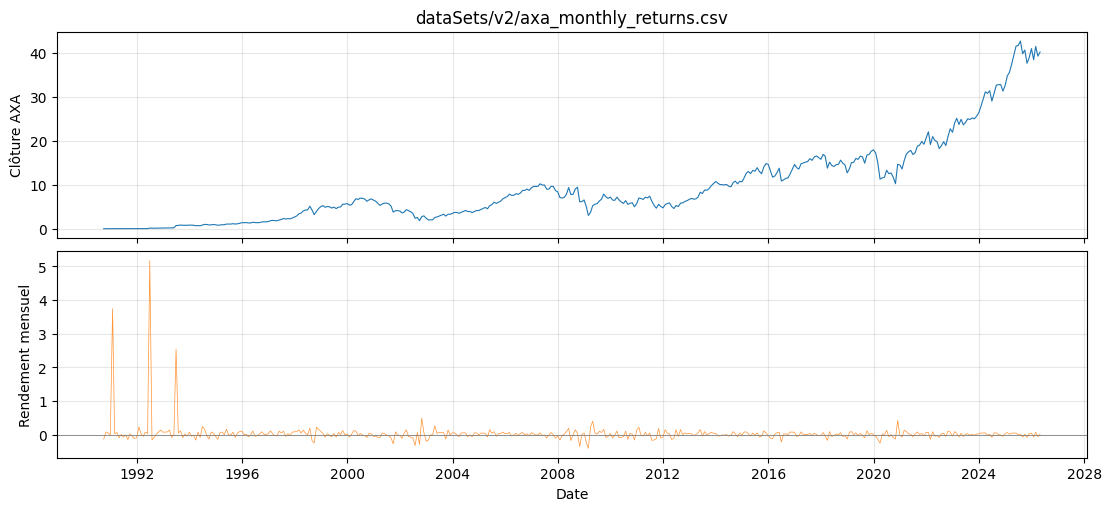

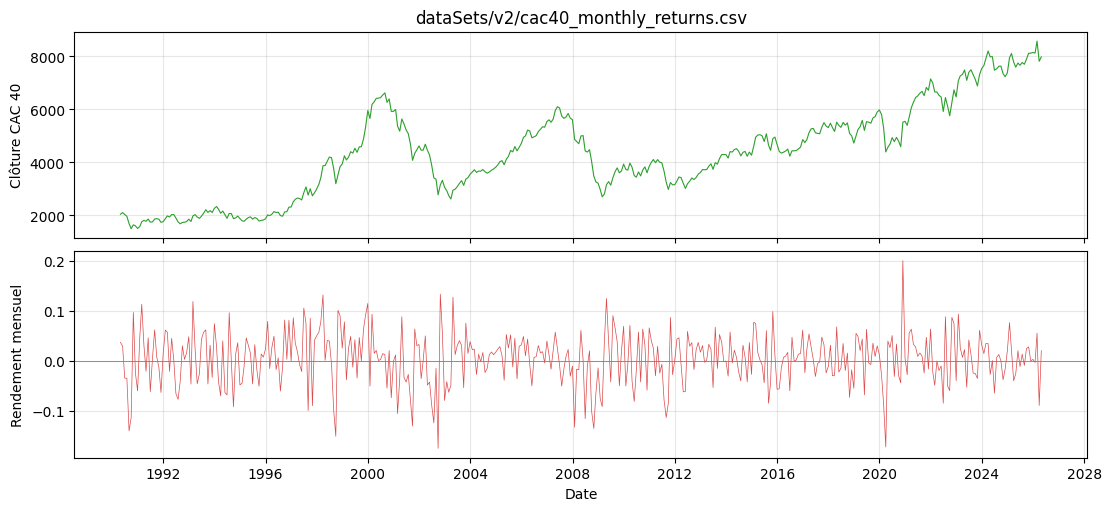

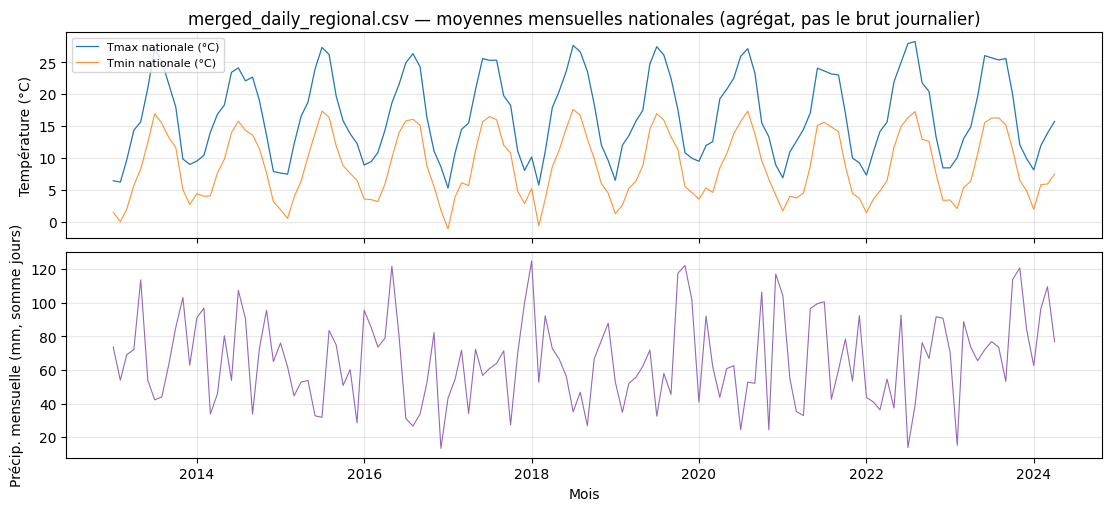

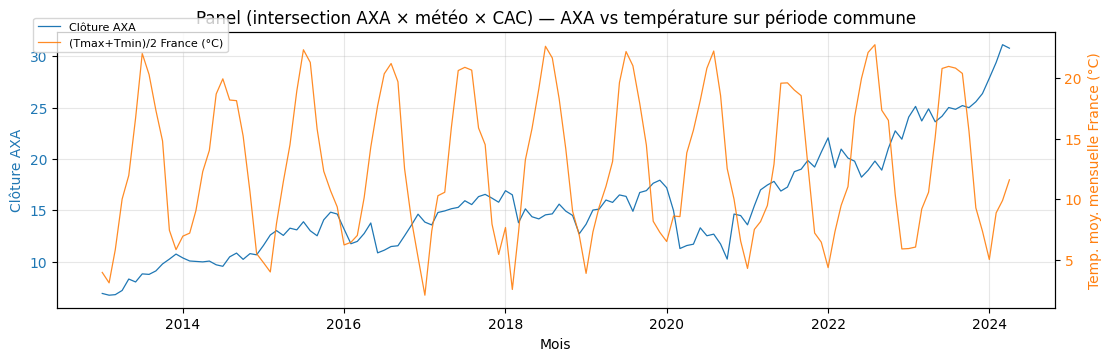

In [17]:
# --- 1) CSV marché AXA ---
axa_raw = pd.read_csv(AXA_PATH, skiprows=[1])
axa_raw["Date"] = pd.to_datetime(axa_raw["Date"])
axa_raw = axa_raw.dropna(subset=["Date"]).sort_values("Date")

fig1, axes1 = plt.subplots(2, 1, sharex=True, figsize=(11, 5), layout="constrained")
axes1[0].plot(axa_raw["Date"], axa_raw["Close"], color="#1f77b4", lw=0.8)
axes1[0].set_ylabel("Clôture AXA")
axes1[0].set_title("dataSets/v2/axa_monthly_returns.csv")
axes1[0].grid(True, alpha=0.3)
axes1[1].plot(
    axa_raw["Date"], axa_raw["Monthly_Return"], color="#ff7f0e", lw=0.5, alpha=0.85
)
axes1[1].axhline(0, color="gray", lw=0.6)
axes1[1].set_ylabel("Rendement mensuel")
axes1[1].set_xlabel("Date")
axes1[1].grid(True, alpha=0.3)
plt.show()

# --- 2) CSV marché CAC 40 ---
cac_raw = pd.read_csv(CAC_PATH, skiprows=[1])
cac_raw["Date"] = pd.to_datetime(cac_raw["Date"])
cac_raw = cac_raw.dropna(subset=["Date"]).sort_values("Date")

fig1b, axes1b = plt.subplots(2, 1, sharex=True, figsize=(11, 5), layout="constrained")
axes1b[0].plot(cac_raw["Date"], cac_raw["Close"], color="#2ca02c", lw=0.8)
axes1b[0].set_ylabel("Clôture CAC 40")
axes1b[0].set_title("dataSets/v2/cac40_monthly_returns.csv")
axes1b[0].grid(True, alpha=0.3)
axes1b[1].plot(
    cac_raw["Date"], cac_raw["Monthly_Return"], color="#d62728", lw=0.5, alpha=0.85
)
axes1b[1].axhline(0, color="gray", lw=0.6)
axes1b[1].set_ylabel("Rendement mensuel")
axes1b[1].set_xlabel("Date")
axes1b[1].grid(True, alpha=0.3)
plt.show()

# --- 3) Agrégat mensuel météo (issu de merged_daily_regional.csv) ---
try:
    m_plot = m_nat.sort_values("month").copy()
except NameError:
    reg = pd.read_csv(WEATHER_PATH, parse_dates=["date"])
    daily_nat = (
        reg.groupby("date", sort=True)
        .agg(
            tmax_nat=("temperature_2m_max", "mean"),
            tmin_nat=("temperature_2m_min", "mean"),
            precip_nat=("precipitation_sum", "mean"),
        )
        .sort_index()
    )
    m_tmp = daily_nat.resample("ME").agg(
        {"tmax_nat": "mean", "tmin_nat": "mean", "precip_nat": "sum"}
    )
    m_tmp = m_tmp.reset_index()
    m_tmp["month"] = m_tmp["date"].dt.to_period("M").dt.to_timestamp()
    m_plot = m_tmp.drop(columns=["date"]).rename(
        columns={
            "tmax_nat": "fr_tmax_m",
            "tmin_nat": "fr_tmin_m",
            "precip_nat": "fr_precip_m",
        }
    ).sort_values("month")

fig2, axes2 = plt.subplots(2, 1, sharex=True, figsize=(11, 5), layout="constrained")
axes2[0].plot(m_plot["month"], m_plot["fr_tmax_m"], label="Tmax nationale (°C)", lw=0.9)
axes2[0].plot(m_plot["month"], m_plot["fr_tmin_m"], label="Tmin nationale (°C)", lw=0.8, alpha=0.85)
axes2[0].set_ylabel("Température (°C)")
axes2[0].set_title(
    "merged_daily_regional.csv — moyennes mensuelles nationales (agrégat, pas le brut journalier)"
)
axes2[0].legend(loc="upper left", fontsize=8)
axes2[0].grid(True, alpha=0.3)
axes2[1].plot(m_plot["month"], m_plot["fr_precip_m"], color="#9467bd", lw=0.8)
axes2[1].set_ylabel("Précip. mensuelle (mm, somme jours)")
axes2[1].set_xlabel("Mois")
axes2[1].grid(True, alpha=0.3)
plt.show()

# --- 4) Panel fusionné (intersection) : AXA × météo sur la même fenêtre ---
try:
    p = panel.sort_values("month").copy()
except NameError:
    raise RuntimeError("Exécuter d’abord la cellule qui construit `panel`.")

t_mean_m = (p["fr_tmax_m"] + p["fr_tmin_m"]) / 2.0
fig3, ax_l = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax_r = ax_l.twinx()
ax_l.plot(p["month"], p["axa_close"], color="#1f77b4", lw=0.9, label="Clôture AXA")
ax_r.plot(
    p["month"],
    t_mean_m,
    color="#ff7f0e",
    lw=0.9,
    alpha=0.9,
    label="(Tmax+Tmin)/2 France (°C)",
)
ax_l.set_xlabel("Mois")
ax_l.set_ylabel("Clôture AXA", color="#1f77b4")
ax_r.set_ylabel("Temp. moy. mensuelle France (°C)", color="#ff7f0e")
ax_l.tick_params(axis="y", labelcolor="#1f77b4")
ax_r.tick_params(axis="y", labelcolor="#ff7f0e")
ax_l.set_title("Panel (intersection AXA × météo × CAC) — AXA vs température sur période commune")
ax_l.grid(True, alpha=0.3)
fig3.legend(
    handles=[*ax_l.get_lines(), *ax_r.get_lines()],
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=8,
)
plt.show()

## 5. Variables explicatives **décalées** (pas de fuite)

On modélise le rendement **du mois courant** `axa_ret` avec uniquement l’**historique** (mois précédents) pour AXA, CAC et météo.


In [18]:
d = panel.copy()
for lag in [1, 2]:
    d[f"axa_l{lag}"] = d["axa_ret"].shift(lag)
    d[f"cac_l{lag}"] = d["cac_ret"].shift(lag)
    d[f"fr_tx_l{lag}"] = d["fr_tmax_m"].shift(lag)
    d[f"fr_pr_l{lag}"] = d["fr_precip_m"].shift(lag)

d["target_up"] = (d["axa_ret"] > 0).astype(int)
model_df = d.dropna().reset_index(drop=True)
print("Rows after lag dropna:", len(model_df))
model_df.head()


Rows after lag dropna: 134


,month,axa_close,axa_ret,fr_tmax_m,fr_tmin_m,fr_precip_m,cac_close,cac_ret,axa_l1,cac_l1,fr_tx_l1,fr_pr_l1,axa_l2,cac_l2,fr_tx_l2,fr_pr_l2,target_up
0,2013-03-01,6.781337,0.007892,9.670699,1.960484,69.100000,3731.419922,0.002262,-0.024560,-0.002572,6.184226,53.900000,0.031380,0.031034,6.409677,73.650000,1
1,2013-04-01,7.188418,0.060030,14.329444,5.673611,72.175000,3856.750000,0.033588,0.007892,0.002262,9.670699,69.100000,-0.024560,-0.002572,6.184226,53.900000,1
2,2013-05-01,8.302216,0.154943,15.658602,8.241129,113.658333,3948.590088,0.023813,0.060030,0.033588,14.329444,72.175000,0.007892,0.002262,9.670699,69.100000,1
3,2013-06-01,8.018038,-0.034229,20.973611,12.446111,53.816667,3738.909912,-0.053103,0.154943,0.023813,15.658602,113.658333,0.060030,0.033588,14.329444,72.175000,0
4,2013-07-01,8.804173,0.098046,27.147849,16.938441,42.216667,3992.689941,0.067875,-0.034229,-0.053103,20.973611,53.816667,0.154943,0.023813,15.658602,113.658333,1


## 6. Corrélations (aperçu)


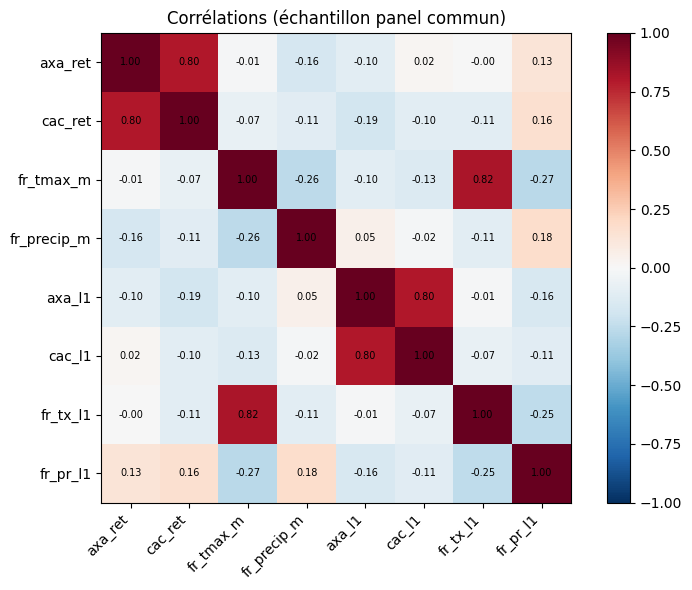

In [19]:
cols = ["axa_ret", "cac_ret", "fr_tmax_m", "fr_precip_m", "axa_l1", "cac_l1", "fr_tx_l1", "fr_pr_l1"]
cm = model_df[cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{cm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax)
plt.title("Corrélations (échantillon panel commun)")
plt.tight_layout()
plt.show()


## 7. Régression OLS — rendement AXA (continu)


In [20]:
import statsmodels.api as sm

# Bloc A : marché seulement
X_a = model_df[["axa_l1", "axa_l2", "cac_l1", "cac_l2"]]
y = model_df["axa_ret"]
X_a = sm.add_constant(X_a)
ols_a = sm.OLS(y, X_a).fit()
print("=== OLS — baseline (lags AXA + CAC) ===")
print(ols_a.summary().tables[1])

# Bloc B : + météo France décalée
X_b = model_df[["axa_l1", "axa_l2", "cac_l1", "cac_l2", "fr_tx_l1", "fr_tx_l2", "fr_pr_l1", "fr_pr_l2"]]
X_b = sm.add_constant(X_b)
ols_b = sm.OLS(y, X_b).fit()
print("\n=== OLS — + température / précip (lags) ===")
print(ols_b.summary().tables[1])
print(f"\nΔ R² ajusté: {ols_b.rsquared_adj - ols_a.rsquared_adj:+.4f}")


=== OLS — baseline (lags AXA + CAC) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0174      0.007      2.567      0.011       0.004       0.031
axa_l1        -0.3031      0.147     -2.067      0.041      -0.593      -0.013
axa_l2        -0.0585      0.147     -0.399      0.691      -0.349       0.232
cac_l1         0.4010      0.241      1.661      0.099      -0.077       0.878
cac_l2        -0.1211      0.241     -0.503      0.616      -0.598       0.356

=== OLS — + température / précip (lags) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0076      0.035     -0.216      0.829      -0.078       0.062
axa_l1        -0.3275      0.150     -2.182      0.031      -0.625      -0.030
axa_l2        -0.1128      0.149     -0.757   

## 8. Régression logistique — probabilité de mois « up »


In [21]:
logit_a = sm.Logit(model_df["target_up"], X_a).fit(disp=False)
logit_b = sm.Logit(model_df["target_up"], X_b).fit(disp=False)
print("Logit baseline — pseudo R²:", f"{logit_a.prsquared:.4f}")
print(logit_b.summary2().tables[1])
print("\nLogit + météo — pseudo R²:", f"{logit_b.prsquared:.4f}")
print(f"Δ pseudo R²: {logit_b.prsquared - logit_a.prsquared:+.4f}")


Logit baseline — pseudo R²: 0.0459
              Coef.  Std.Err.         z     P>|z|     [0.025     0.975]
const     -0.269739  0.995711 -0.270901  0.786467  -2.221296   1.681818
axa_l1    -9.525004  4.509023 -2.112432  0.034649 -18.362526  -0.687482
axa_l2     0.037995  4.171087  0.009109  0.992732  -8.137185   8.213176
cac_l1    10.827618  7.182867  1.507423  0.131702  -3.250542  24.905779
cac_l2    -5.727037  6.873254 -0.833235  0.404712 -19.198367   7.744293
fr_tx_l1  -0.012501  0.053738 -0.232622  0.816055  -0.117824   0.092823
fr_tx_l2   0.031024  0.052122  0.595216  0.551699  -0.071134   0.133181
fr_pr_l1   0.002952  0.007546  0.391186  0.695660  -0.011837   0.017741
fr_pr_l2   0.004406  0.007767  0.567249  0.570545  -0.010817   0.019628

Logit + météo — pseudo R²: 0.0516
Δ pseudo R²: +0.0057


## 9. (Optionnel) Gradient boosting — accuracy test chronologique


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

n = len(model_df)
split = int(n * 0.8)
feat_mkt = ["axa_l1", "axa_l2", "cac_l1", "cac_l2"]
feat_all = feat_mkt + ["fr_tx_l1", "fr_tx_l2", "fr_pr_l1", "fr_pr_l2"]
X0 = model_df[feat_mkt]
X1 = model_df[feat_all]
y_bin = model_df["target_up"]
X0_tr, X0_te = X0.iloc[:split], X0.iloc[split:]
X1_tr, X1_te = X1.iloc[:split], X1.iloc[split:]
y_tr, y_te = y_bin.iloc[:split], y_bin.iloc[split:]

maj = int(y_te.mean() >= 0.5)
maj_acc = (y_te == maj).mean()
gb0 = GradientBoostingClassifier(random_state=42, max_depth=3, n_estimators=200)
gb1 = GradientBoostingClassifier(random_state=42, max_depth=3, n_estimators=200)
gb0.fit(X0_tr, y_tr)
gb1.fit(X1_tr, y_tr)
p0 = gb0.predict(X0_te)
p1 = gb1.predict(X1_te)
print(f"Test window: rows {split}..{n-1} (n_test={len(y_te)})")
print(f"Majority-class accuracy: {maj_acc:.4f}")
print(f"GB market-only     acc={accuracy_score(y_te, p0):.4f}  F1={f1_score(y_te, p0, zero_division=0):.4f}")
print(f"GB + weather       acc={accuracy_score(y_te, p1):.4f}  F1={f1_score(y_te, p1, zero_division=0):.4f}")


Test window: rows 107..133 (n_test=27)
Majority-class accuracy: 0.5926
GB market-only     acc=0.3333  F1=0.3571
GB + weather       acc=0.4074  F1=0.4667


### Graphique — baseline marché vs modèle enrichi (jeu de test)

Même **découpe chronologique** que la section 9 (**80 %** train / **20 %** test). **Précision** et **F1** (classe « hausse »). La **ligne pointillée** : baseline naïve consistant à prédire **toujours un mois positif** (accuracy = proportion de mois haussiers sur le test).

Modèles : **régression logistique** et **forêt aléatoire** (comme le notebook S&P × GISS), avec **lags AXA + CAC** vs **+ lags température / précipitations France**.

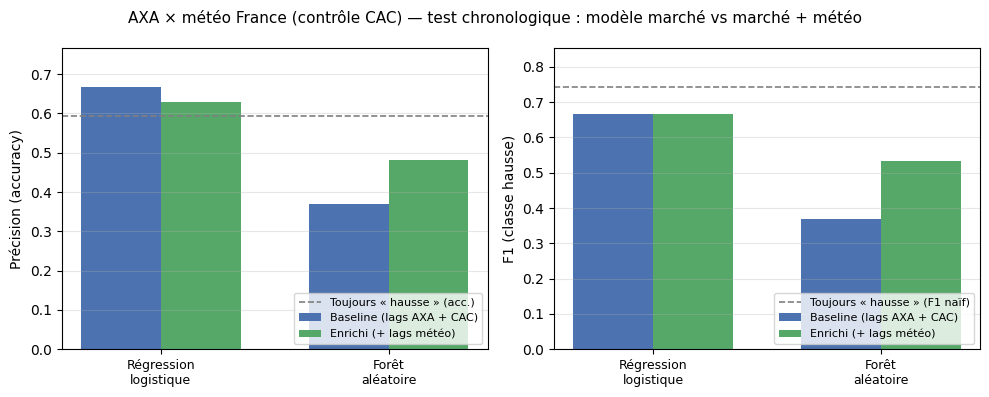

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    _ = model_df.shape
except NameError as e:
    raise RuntimeError(
        "Exécuter d'abord les cellules qui construisent model_df (lags + target_up)."
    ) from e

TRAIN_FRAC = 0.8
n = len(model_df)
split = int(n * TRAIN_FRAC)
feat_mkt = ["axa_l1", "axa_l2", "cac_l1", "cac_l2"]
feat_all = feat_mkt + ["fr_tx_l1", "fr_tx_l2", "fr_pr_l1", "fr_pr_l2"]
X_m = model_df[feat_mkt]
X_a = model_df[feat_all]
y = model_df["target_up"].astype(int)
X_tr_m, X_te_m = X_m.iloc[:split], X_m.iloc[split:]
X_tr_a, X_te_a = X_a.iloc[:split], X_a.iloc[split:]
y_tr, y_te = y.iloc[:split], y.iloc[split:]


def make_lr():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                    solver="lbfgs",
                ),
            ),
        ]
    )


def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def _test_scores(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba1 = model.predict_proba(X_test)[:, 1]
        y_pred = (proba1 >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    return acc, f1


model_specs = [
    ("Régression logistique", make_lr),
    ("Forêt aléatoire", make_rf),
]
acc_base, acc_enr, f1_base, f1_enr = [], [], [], []
for _label, factory in model_specs:
    ab, fb = _test_scores(factory(), X_tr_m, X_te_m, y_tr, y_te)
    ae, fe = _test_scores(factory(), X_tr_a, X_te_a, y_tr, y_te)
    acc_base.append(ab)
    acc_enr.append(ae)
    f1_base.append(fb)
    f1_enr.append(fe)

x = np.arange(len(model_specs))
width = 0.35
p_up_test = float(y_te.mean())
acc_naive_up = p_up_test
f1_naive_up = (2 * p_up_test / (1 + p_up_test)) if p_up_test > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
configs = [
    (acc_base, acc_enr, "Précision (accuracy)", acc_naive_up, "Toujours « hausse » (acc.)"),
    (f1_base, f1_enr, "F1 (classe hausse)", f1_naive_up, "Toujours « hausse » (F1 naïf)"),
]
for ax, (base, enr, title, ref_line, ref_label) in zip(axes, configs):
    ax.bar(x - width / 2, base, width, label="Baseline (lags AXA + CAC)", color="#4C72B0")
    ax.bar(x + width / 2, enr, width, label="Enrichi (+ lags météo)", color="#55A868")
    ax.axhline(ref_line, color="gray", linestyle="--", linewidth=1.2, label=ref_label)
    ax.set_xticks(x)
    ax.set_xticklabels([m[0].replace(" ", "\n") for m in model_specs], fontsize=9)
    ax.set_ylabel(title)
    top = max(ref_line, *base, *enr)
    ax.set_ylim(0, min(1.05, top * 1.12 + 0.02))
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "AXA × météo France (contrôle CAC) — test chronologique : modèle marché vs marché + météo",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## Lecture rapide

- **OLS / logit :** regardez le **signe** et la **p-valeur** (ou intervalle) des coefficients météo ; un **R² ajusté** ou pseudo R² qui **n’augmente quasiment pas** suggère peu d’association linéaire une fois le marché contrôlé.
- **GB :** compare surtout **Δ accuracy** entre les deux modèles sur le **même** test ; restez prudent si `n_test` est petit.

Pour la soutenance : une phrase du type *« association statistique faible / non significative après contrôle du CAC »* est un **résultat valide**.
